In [2]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")
check_installation_and_install("wfdb")

pandas is installed
matplotlib is installed
numpy is installed
wfdb is installed


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


## Load Data

In [4]:
file_directory = "./Cleaned_Data"

df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

df.head()

,RXPACC,CIR745,MAX_NOISE,CIR740,CIR749,CIR_PWR,CIR750,CIR351,CIR333,CIR349,...,CIR582,CIR86,CIR326,CIR526,CIR646,CIR94,CIR550,NLOS,RANGE,location
0,611.0,11573.0,967.0,266.0,9621.0,11855.0,8303.0,289.0,182.0,179.0,...,313.0,214.0,150.0,221.0,301.0,409.0,168.0,0.0,3.90,Office 1
1,447.0,123.0,1133.0,10.0,1840.0,18968.0,5244.0,203.0,247.0,123.0,...,110.0,350.0,263.0,171.0,222.0,24.0,65.0,0.0,0.66,Office 1
2,723.0,754.0,894.0,500.0,4489.0,14699.0,2992.0,423.0,265.0,205.0,...,236.0,46.0,172.0,97.0,255.0,261.0,412.0,1.0,7.86,Office 1
3,1024.0,343.0,1127.0,241.0,1424.0,8748.0,2907.0,297.0,250.0,157.0,...,375.0,396.0,213.0,439.0,268.0,393.0,374.0,1.0,3.48,Office 1
4,276.0,2479.0,1744.0,280.0,16162.0,11380.0,19583.0,144.0,240.0,42.0,...,266.0,289.0,68.0,79.0,151.0,248.0,217.0,0.0,1.19,Office 1


## Split data 

In [5]:
original_df = df

X = original_df.drop(['NLOS', 'location'], axis=1)
y = original_df['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# print(X_train.describe())


# Classification of NLOS and LOS data

## Decision Tree Classification

In [14]:
dtc = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dtc = dtc.fit(X_train,y_train)

dtc_y_pred = dtc.predict(X_test)


rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc = rfc.fit(X_train,y_train)

rfc_y_pred = rfc.predict(X_test)

### Accuracy Testing

In [15]:
print("Decision Tree Classifier Accuracy:",metrics.accuracy_score(y_test, dtc_y_pred))

print("Random Forest Classifier Accuracy:",metrics.accuracy_score(y_test, rfc_y_pred))

Decision Tree Classifier Accuracy: 0.8736653578563064
Random Forest Classifier Accuracy: 0.9024591857821864


## KNN

In [7]:
numNeighbors = [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    Y_predTrain = clf1.predict(X_train)
    Y_predTest = clf1.predict(X_test)

    train_accuracy = accuracy_score(y_train, Y_predTrain)
    test_accuracy = accuracy_score(y_test, Y_predTest)

    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

    print(f'k={k}, Training Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')    

k=1, Training Accuracy: 1.0000, Test Accuracy: 0.7378
k=2, Training Accuracy: 0.8576, Test Accuracy: 0.7552
k=3, Training Accuracy: 0.8679, Test Accuracy: 0.7654
k=4, Training Accuracy: 0.8350, Test Accuracy: 0.7732
k=5, Training Accuracy: 0.8393, Test Accuracy: 0.7757
k=6, Training Accuracy: 0.8244, Test Accuracy: 0.7797
k=7, Training Accuracy: 0.8276, Test Accuracy: 0.7814
k=10, Training Accuracy: 0.8145, Test Accuracy: 0.7862
k=11, Training Accuracy: 0.8146, Test Accuracy: 0.7860
k=12, Training Accuracy: 0.8100, Test Accuracy: 0.7861
k=13, Training Accuracy: 0.8114, Test Accuracy: 0.7876
k=14, Training Accuracy: 0.8066, Test Accuracy: 0.7883
k=15, Training Accuracy: 0.8074, Test Accuracy: 0.7882
k=16, Training Accuracy: 0.8058, Test Accuracy: 0.7894
k=17, Training Accuracy: 0.8047, Test Accuracy: 0.7889
k=18, Training Accuracy: 0.8024, Test Accuracy: 0.7887
k=19, Training Accuracy: 0.8034, Test Accuracy: 0.7896
k=20, Training Accuracy: 0.8005, Test Accuracy: 0.7909
k=25, Training Ac

## Neural Network

hidden_layer_sizes=(5, 5, 5), Training Accuracy: 0.8609, Test Accuracy: 0.8620
hidden_layer_sizes=(6, 6, 6), Training Accuracy: 0.8556, Test Accuracy: 0.8562
hidden_layer_sizes=(7, 7, 7), Training Accuracy: 0.8421, Test Accuracy: 0.8387
hidden_layer_sizes=(10, 10, 10), Training Accuracy: 0.8586, Test Accuracy: 0.8609
hidden_layer_sizes=(20, 20, 20), Training Accuracy: 0.8602, Test Accuracy: 0.8586
hidden_layer_sizes=(30, 30, 30), Training Accuracy: 0.8605, Test Accuracy: 0.8598
hidden_layer_sizes=(40, 40, 40), Training Accuracy: 0.8410, Test Accuracy: 0.8405


Text(0, 0.5, 'Accuracy')

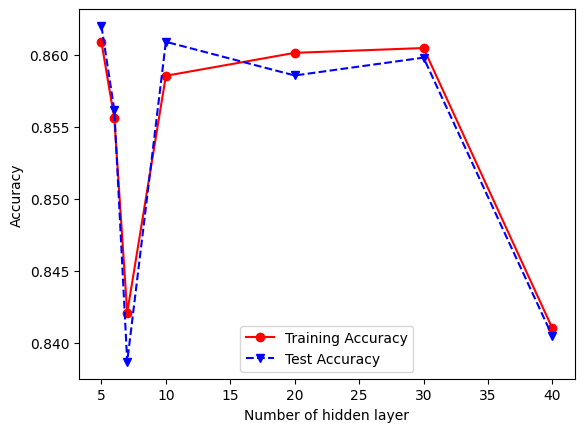

In [8]:
hidden_layer_sizes = [(5,5,5), (6,6,6), (7,7,7),(10,10,10), (20,20,20), (30,30,30), (40,40,40)]
trainAcc = []
testAcc = []

for k in hidden_layer_sizes:
    clf6 = MLPClassifier(solver='adam',hidden_layer_sizes=k, learning_rate='adaptive',random_state=1,max_iter=1000)
    clf6.fit(X_train, y_train)
    Y_predTrain = clf6.predict(X_train)
    Y_predTest = clf6.predict(X_test)
    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))
    print(f'hidden_layer_sizes={k}, Training Accuracy: {accuracy_score(y_train, Y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, Y_predTest):.4f}')
    
hidden_layer_size=[x[0] for x in hidden_layer_sizes]
plt.plot(hidden_layer_size, trainAcc, 'ro-', hidden_layer_size, testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Number of hidden layer')
plt.ylabel('Accuracy')

# Prediction of range

## Multilinear Regression

In [19]:
original_df_range = df

X = original_df_range.drop(['RANGE', 'location'], axis=1)
y = original_df_range['RANGE']

X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.35, random_state=42)

regr = linear_model.LinearRegression()
regr.fit(X_train_range, y_train_range) 

y_pred_range = regr.predict(X_test_range)


### Accuracy Testing

In [20]:
# Evaluate the model
mse = mean_squared_error(y_test_range, y_pred_range)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 3.1415
R-squared: 0.4308
